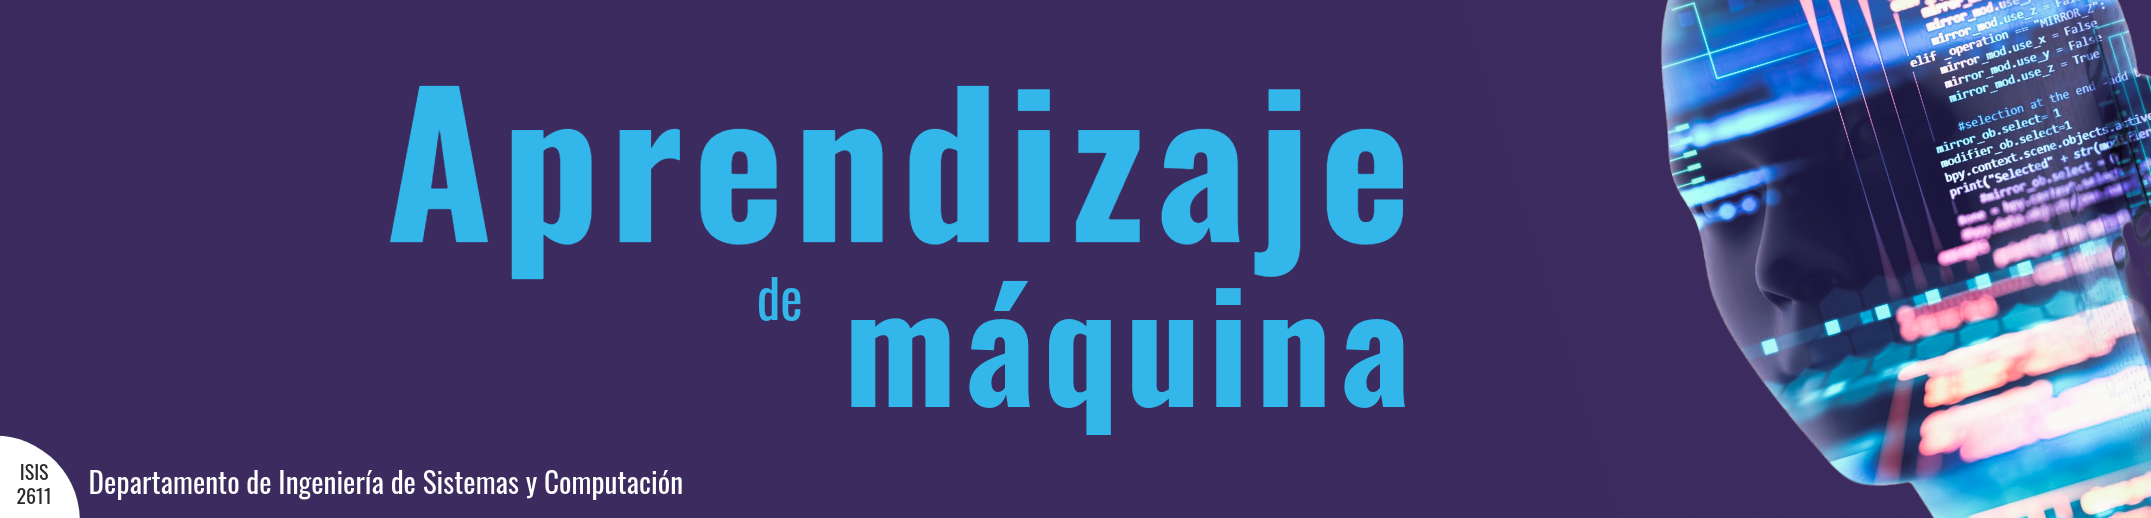


# Competencia — Aprendizaje de Máquina 2026-10
## Parte 1: Clasificación de Textos con Machine Learning Clásico

En este notebook abordaremos el problema de clasificación de textos según su **década de origen**. El objetivo principal es desarrollar un modelo capaz de predecir, dado un párrafo como entrada, la década en la que fue escrito. Trabajaremos exclusivamente con **técnicas clásicas de aprendizaje automático**, sin recurrir a redes neuronales ni arquitecturas profundas.

El dataset contiene textos históricos con señales temporales en el vocabulario, la sintaxis y la estructura del lenguaje. Por tanto, una parte importante del trabajo consiste en **representar adecuadamente el texto** antes de entrenar cualquier modelo. A lo largo del notebook podrás identificar las decisiones de preprocesamiento y su impacto en el desempeño del clasificador.

A continuación se presentan los bloques que se desarrollarán:

1. **Importación de librerías**
2. **Carga y exploración de los datos (EDA)**
3. **Preprocesamiento del texto**
4. **Partición de los datos**
5. **Representación del texto (vectorización)**
6. **Construcción del pipeline y modelos**
7. **Búsqueda de hiperparámetros**
8. **Evaluación y comparación de modelos**
9. **Análisis de importancia de features**
10. **Generación del archivo de respuesta para Kaggle**
11. **Guardado del modelo**

## 1. Importación de Librerías

En esta sección se importan todas las librerías necesarias para el desarrollo del notebook. Se organizan por categoría para facilitar su lectura:

- **Manejo de datos:** `pandas`, `numpy`
- **Procesamiento de texto:** `nltk` para tokenización, stopwords y stemming
- **Vectorización:** `CountVectorizer` y `TfidfVectorizer` de scikit-learn
- **Modelos clásicos:** Regresión Logística, Árbol de Decisión, Random Forest, Naive Bayes y KNN
- **Validación:** `StratifiedKFold` y `GridSearchCV` para búsqueda de hiperparámetros con datos balanceados
- **Métricas:** `f1_score` macro como métrica principal, dado que las clases (décadas) pueden estar desbalanceadas
- **Utilidades:** `scipy.sparse` para combinar representaciones, `joblib` para guardar el modelo entrenado

In [4]:
# ─────────────────────────────────────────────
# INSTALACIÓN AUTOMÁTICA DE DEPENDENCIAS
# ─────────────────────────────────────────────

import subprocess
import sys

def instalar_si_falta(paquete, nombre_import=None):
    """
    Intenta importar un paquete. Si no existe, lo instala automáticamente.
    
    Args:
        paquete: nombre del paquete en pip (ej: 'scikit-learn')
        nombre_import: nombre para importar (ej: 'sklearn'). Si es None, usa 'paquete'
    """
    nombre_import = nombre_import or paquete
    try:
        __import__(nombre_import)
    except ImportError:
        print(f"📦 Instalando {paquete}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", paquete, "-q"])
        print(f"✅ {paquete} instalado correctamente")

# Instalar dependencias requeridas
dependencias = [
    ('pandas',          'pandas'),
    ('numpy',           'numpy'),
    ('nltk',            'nltk'),
    ('scikit-learn',    'sklearn'),
    ('scipy',           'scipy'),
    ('joblib',          'joblib'),
    ('matplotlib',      'matplotlib'),
    ('seaborn',         'seaborn'),
]

print("🔍 Verificando dependencias...\n")
for paquete, nombre_import in dependencias:
    instalar_si_falta(paquete, nombre_import)

print("\n✅ Todas las dependencias están disponibles\n")

🔍 Verificando dependencias...


✅ Todas las dependencias están disponibles



In [ ]:
# ─────────────────────────────────────────────
# 1. IMPORTACIÓN DE LIBRERÍAS
# ─────────────────────────────────────────────

# Manejo de datos
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# ── Preprocesamiento de texto ──
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('punkt',        quiet=True)
nltk.download('punkt_tab',    quiet=True)
nltk.download('stopwords',    quiet=True)
nltk.download('wordnet',      quiet=True)

# ── Vectorización ──
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ── Partición y validación ──
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
)

# ── Pipeline y transformadores ──
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer

# ── Modelos clásicos (Parte 1 — sin deep learning) ──
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import LinearSVC
from sklearn.naive_bayes     import MultinomialNB, ComplementNB
from sklearn.neighbors       import KNeighborsClassifier

# ── Métricas ──
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
)

# ── Utilidades ──
from scipy.sparse import hstack, csr_matrix
import joblib

# ── Visualización ──
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


## 2. Carga y Exploración de los Datos (EDA)

Antes de construir cualquier modelo, es fundamental entender la estructura y calidad de los datos. En esta sección verificamos:

- **Completitud:** presencia de valores nulos
- **Unicidad:** textos duplicados que podrían inflar el desempeño
- **Validez:** rangos coherentes en la variable objetivo `decade`
- **Balance de clases:** distribución de textos por década, ya que un desbalance significativo afecta la elección de la métrica y la estrategia de entrenamiento

El dataset contiene dos archivos:
- `train.csv`: textos etiquetados con su década de origen (variable `decade` expresada como los tres primeros dígitos del año, por ejemplo `157` para la década de 1570)
- `eval.csv`: textos sin etiqueta sobre los cuales se generarán las predicciones para Kaggle

In [6]:
# ─────────────────────────────────────────────
# 2. CARGA Y EXPLORACIÓN DE DATOS (EDA)
# ─────────────────────────────────────────────

# ── Carga de archivos ──
df_train = pd.read_csv('./Data/train.csv')
df_eval  = pd.read_csv('./Data/eval.csv')

# Copia de trabajo para no modificar los datos originales
data = df_train.copy()

# ── Dimensiones ──
print(f"{'Train shape:':<20} {df_train.shape}")
print(f"{'Eval shape:':<20} {df_eval.shape}")

# ── Primeras filas ──
print("\n── Primeras filas del conjunto de entrenamiento ──")
display(df_train.head())

Train shape:         (31403, 2)
Eval shape:          (3490, 2)

── Primeras filas del conjunto de entrenamiento ──


,text,decade
0,\r\nHonorarias ¡jubiladas. 57 \r\ndit.ad Ponte...,164
1,"gone. Sus amigos , sus clientes, todo \r\ncuan...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157
3,Caistro el M a y o r a i .] Del ape...,163
4,\r\nlos que panden macho ; y \r\notros e...,166


El conjunto de entrenamiento cuenta con **31.403 textos** y 2 columnas (`text`, `decade`). El conjunto de evaluación tiene **3.490 textos**. Ambos datasets están correctamente estructurados.

In [7]:
# ─────────────────────────────────────────────
# 2.1 Revisión de calidad
# ─────────────────────────────────────────────
print("\n── Tipos de datos ──")
print(df_train.dtypes)

print("\n── Valores nulos por columna ──")
print(df_train.isnull().sum())

print("\n── Textos duplicados ──")
n_dup = df_train['text'].duplicated().sum()
print(f"Duplicados en 'text': {n_dup}")


── Tipos de datos ──
text        str
decade    int64
dtype: object

── Valores nulos por columna ──
text      0
decade    0
dtype: int64

── Textos duplicados ──
Duplicados en 'text': 51


No hay valores nulos en ninguna columna. Se detectaron **51 textos duplicados** (<0.2% del total), los cuales serán eliminados en preprocesamiento para evitar que el mismo texto aparezca en entrenamiento y validación simultáneamente. La variable `decade` cubre desde **150** (década de 1500) hasta **188** (década de 1880), con **39 clases únicas**, confirmando que estamos ante un problema de **clasificación multiclase** de alta granularidad.

In [8]:
# ─────────────────────────────────────────────
# 2.2 Distribución de clases
# ─────────────────────────────────────────────
decade_counts = df_train['decade'].value_counts().sort_index()

print("\n── Distribución de décadas ──")
print(decade_counts.to_string())

print(f"\nNúmero de clases únicas: {df_train['decade'].nunique()}")
print(f"Década más antigua:      {df_train['decade'].min()}")
print(f"Década más reciente:     {df_train['decade'].max()}")


── Distribución de décadas ──
decade
150    786
151    812
152    785
153    775
154    830
155    836
156    792
157    827
158    778
159    802
160    848
161    787
162    808
163    827
164    804
165    814
166    779
167    831
168    822
169    771
170    833
171    816
172    842
173    802
174    807
175    817
176    754
177    782
178    831
179    809
180    825
181    795
182    808
183    794
184    802
185    803
186    773
187    787
188    809

Número de clases únicas: 39
Década más antigua:      150
Década más reciente:     188


La distribución de textos por década es **notablemente uniforme**: todas las clases tienen entre 750 y 850 ejemplos, sin ninguna categoría dominante ni subrepresentada. Esto es favorable para el entrenamiento, aunque con 39 clases el problema sigue siendo desafiante. Usaremos `f1_macro` como métrica principal para tratar todas las décadas por igual, y `stratify=y` en la partición para preservar esta distribución.

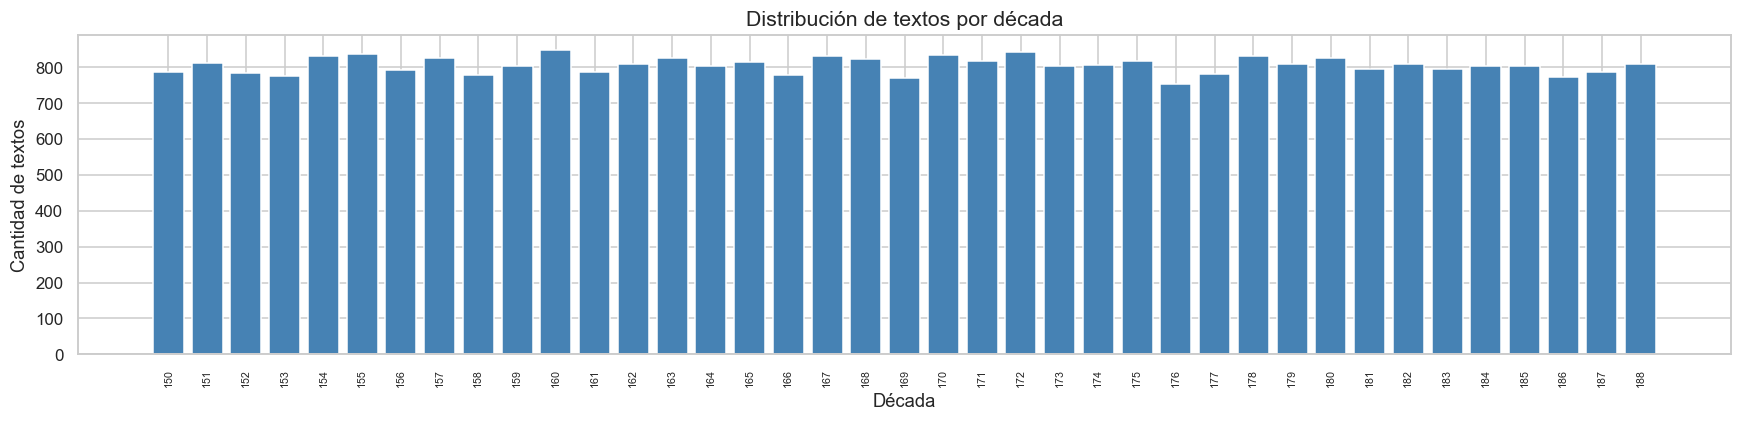

In [9]:
# ─────────────────────────────────────────────
# 2.3 Visualización distribución de clases
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(decade_counts.index.astype(str), decade_counts.values, color='steelblue', edgecolor='white')
ax.set_title('Distribución de textos por década', fontsize=14)
ax.set_xlabel('Década')
ax.set_ylabel('Cantidad de textos')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

La distribución de textos por década es **notablemente uniforme**: todas las clases tienen entre 750 y 850 ejemplos aproximadamente, sin ninguna categoría dominante ni subrepresentada. Las décadas con más ejemplos son **160** (~848) y **155** (~836), mientras que las menos representadas son **176** (~752) y **169** (~771), pero la diferencia entre la clase más grande y la más pequeña es de apenas ~100 textos. Esto es favorable para el entrenamiento ya que no será necesario aplicar técnicas de balanceo como oversampling. Sin embargo, con **39 clases** el problema sigue siendo desafiante — el azar equivale a un accuracy de apenas **~2.6%**. Por esto usaremos `f1_macro` como métrica principal para tratar todas las décadas por igual, y `stratify=y` en la partición train/test para preservar esta distribución uniforme en ambos conjuntos.


── Estadísticas de longitud de textos ──
       text_len  word_count
count   31403.0     31403.0
mean      530.1        82.3
std       539.6        82.4
min       120.0         3.0
25%       185.0        30.0
50%       321.0        50.0
75%       655.0       102.0
max      7480.0      1146.0


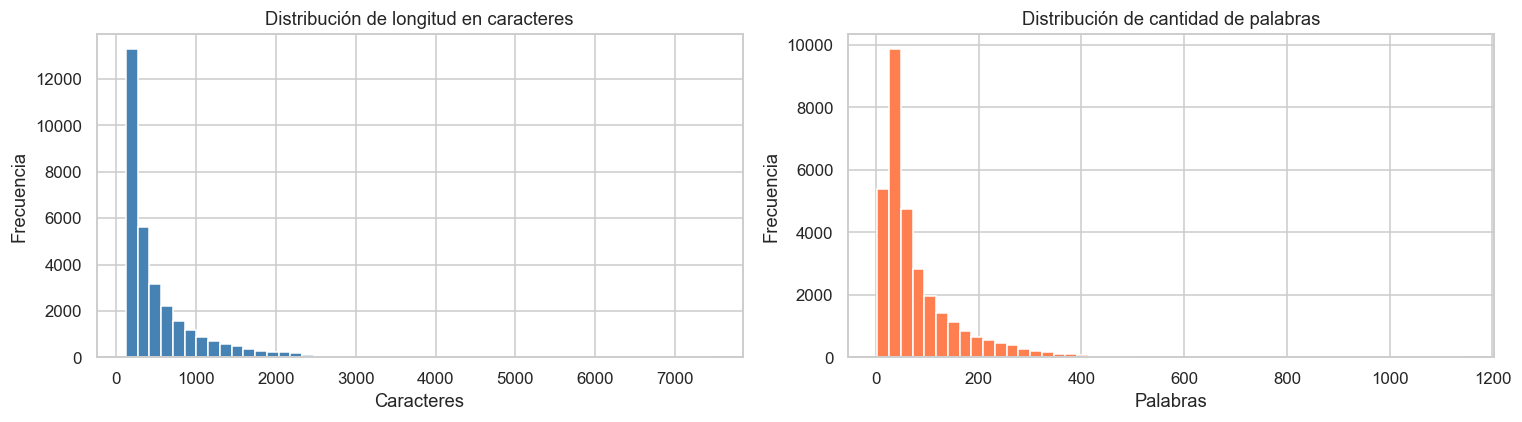

In [10]:
# ─────────────────────────────────────────────
# 2.4 Longitud de los textos
# ─────────────────────────────────────────────
# La longitud del texto puede variar por época (textos medievales más cortos
# por fragmentación de OCR vs. textos modernos más completos)
data['text_len']   = data['text'].str.len()
data['word_count'] = data['text'].str.split().str.len()

print("\n── Estadísticas de longitud de textos ──")
print(data[['text_len', 'word_count']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(data['text_len'],   bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de longitud en caracteres')
axes[0].set_xlabel('Caracteres')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(data['word_count'], bins=50, color='coral',     edgecolor='white')
axes[1].set_title('Distribución de cantidad de palabras')
axes[1].set_xlabel('Palabras')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Ambas distribuciones son **asimétricas a la derecha**: la mayoría de los textos tiene entre 50 y 200 palabras, con una cola de fragmentos más largos de hasta ~1.200 palabras. La brevedad de los textos es un reto para la clasificación ya que con pocos tokens el vocabulario disponible para inferir la época es limitado. Esto refuerza la importancia de complementar la vectorización TF-IDF con features lingüísticas adicionales como longitud de oraciones, riqueza léxica y ratio de puntuación.

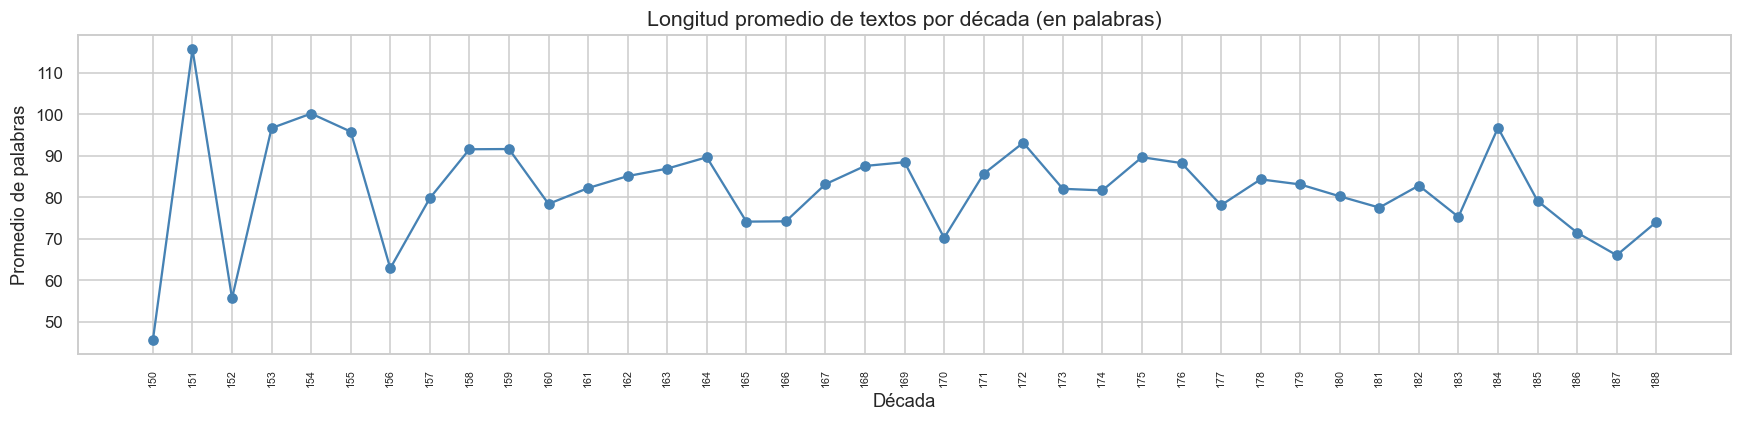

In [11]:
# ─────────────────────────────────────────────
# 2.5 Longitud promedio por década
# ─────────────────────────────────────────────
avg_len = data.groupby('decade')['word_count'].mean().sort_index()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(avg_len.index.astype(str), avg_len.values, marker='o', color='steelblue', linewidth=1.5)
ax.set_title('Longitud promedio de textos por década (en palabras)', fontsize=14)
ax.set_xlabel('Década')
ax.set_ylabel('Promedio de palabras')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

La longitud promedio oscila entre ~48 y ~115 palabras sin una tendencia temporal clara, lo que indica que la longitud depende más del tipo de fragmento digitalizado que de una evolución histórica sistemática. Por tanto, no es un predictor confiable de la época por sí sola, pero puede aportar como feature auxiliar combinada con otras señales lingüísticas.

## 3. Preprocesamiento del Texto

El preprocesamiento de texto histórico requiere decisiones cuidadosas. A diferencia de texto moderno, en este corpus conviven:
- **Ruido de OCR:** caracteres mal reconocidos, palabras partidas con guiones, símbolos extraños (`»`, `«`, `£`)
- **Ortografía histórica:** formas antiguas del español y latín que son señales temporales valiosas
- **Variación tipográfica:** uso de mayúsculas, puntuación y dígitos que varía entre épocas

Por esto, la limpieza debe ser **mínima y quirúrgica**: eliminar solo el ruido técnico de digitalización, pero **preservar** las señales lingüísticas que permiten al modelo distinguir épocas. Limpiar agresivamente (por ejemplo, eliminar puntuación o pasar todo a minúsculas) destruiría features que según Pinto et al. (2025) son de las más discriminativas a nivel de década.

Esta sección se divide en dos partes:
- **3.1 Limpieza inicial:** eliminación de artefactos de OCR y normalización de espacios
- **3.2 Feature engineering:** extracción de features lingüísticas numéricas inspiradas en Pinto et al. (2025)

### 3.1 Limpieza Inicial

Se aplica una limpieza mínima que corrige únicamente los artefactos técnicos de digitalización sin alterar el contenido lingüístico del texto.

In [12]:
# ─────────────────────────────────────────────
# 3.1 LIMPIEZA INICIAL
# ─────────────────────────────────────────────

# Verificar columnas disponibles
print("Columnas train:", data.columns.tolist())
print("Columnas eval: ", df_eval.columns.tolist())

# Eliminar duplicados detectados en el EDA
data = data.drop_duplicates(subset='text').reset_index(drop=True)
print(f"\nRegistros tras eliminar duplicados: {len(data)}")

def clean_text(text):
    """
    Limpieza mínima orientada a preservar señales temporales.
    Solo elimina artefactos técnicos de OCR y digitalización.
    """
    text = str(text)
    text = text.replace('-\n', '')    # palabras partidas por salto de línea
    text = text.replace('\n', ' ')    # saltos de línea restantes
    text = text.replace('»', ' ')     # comillas tipográficas (artefacto OCR)
    text = text.replace('«', ' ')
    text = text.replace('£', ' ')     # símbolo de libra (artefacto de codificación)
    while '  ' in text:               # colapsar espacios múltiples
        text = text.replace('  ', ' ')
    return text.strip()

# Aplicar a train y eval
data['text_clean']    = data['text'].apply(clean_text)
df_eval['text_clean'] = df_eval['text'].apply(clean_text)

print("✅ Limpieza aplicada")
print(f"Textos vacíos tras limpieza: {data['text_clean'].str.strip().eq('').sum()}")

# Comparar un ejemplo antes y después
idx = 10
print(f"\n── Ejemplo (índice {idx}) ──")
print("ANTES:\n",    data['text'].iloc[idx])
print("\nDESPUÉS:\n", data['text_clean'].iloc[idx])

Columnas train: ['text', 'decade', 'text_len', 'word_count']
Columnas eval:  ['id', 'text']

Registros tras eliminar duplicados: 31352
✅ Limpieza aplicada
Textos vacíos tras limpieza: 0

── Ejemplo (índice 10) ──
ANTES:
 blar enla oracion de pereza, i floxedad ,i por eltar medio: 
dormido», ifi hablara,fe defpertara,i'avivara para la orar 
cidadetó 3 fracasado desa 
Tanbien dize Gerfon,que es buénremedio para las dis 

DESPUÉS:
 Tanbien dize Gerfon,que es buénremedio para las disla orar  


La limpieza elimina únicamente artefactos técnicos de OCR: palabras partidas por salto de línea, comillas tipográficas y símbolos de codificación incorrecta. No se eliminan stopwords, puntuación ni se aplica stemming en esta etapa, ya que estas características son insumos para las features lingüísticas que se extraen a continuación. Tras la limpieza no quedan textos vacíos.

### 3.2 Feature Engineering — Features Lingüísticas

Inspirados en Pinto et al. (2025), quienes demuestran que las features de **estructura léxica** son las más discriminativas para clasificación a nivel de década, extraemos seis métricas numéricas por texto. Estas features capturan aspectos del lenguaje que evolucionan a lo largo de los siglos y que el TF-IDF no puede representar directamente:

| Feature | Descripción | Justificación |
|---|---|---|
| `avg_word_len` | Longitud promedio de palabras | El latín y el español antiguo usan palabras más largas y compuestas |
| `lexical_richness` | Ratio tipos/tokens (TTR) | La riqueza vocabular varía entre épocas |
| `avg_sent_len` | Longitud promedio de oraciones | Las oraciones históricas tienden a ser más largas y subordinadas |
| `punct_density` | Proporción de signos de puntuación | Las convenciones tipográficas evolucionan entre siglos |
| `upper_ratio` | Proporción de mayúsculas | El uso de mayúsculas en sustantivos era común en textos antiguos |
| `digit_ratio` | Proporción de dígitos | Los textos más modernos tienden a incorporar más referencias numéricas |

In [13]:
# ─────────────────────────────────────────────
# 3.2 FEATURE ENGINEERING — FEATURES LINGÜÍSTICAS
# ─────────────────────────────────────────────

def extract_features(text):
    words     = text.split()
    sentences = [s.strip() for s in
                 text.replace('?', '.').replace('!', '.').split('.')
                 if s.strip()]

    # Longitud promedio de palabras
    avg_word_len = (sum(len(w) for w in words) / len(words)
                    if words else 0)
    # Riqueza léxica — type-token ratio
    lexical_richness = (len(set(words)) / len(words)
                        if words else 0)
    # Longitud promedio de oraciones
    avg_sent_len = (len(words) / len(sentences)
                    if sentences else 0)
    # Densidad de puntuación
    punct_density = (sum(1 for c in text if c in '.,;:!?()[]{}') / len(text)
                     if text else 0)
    # Proporción de mayúsculas
    upper_ratio = (sum(1 for c in text if c.isupper()) / len(text)
                   if text else 0)
    # Proporción de dígitos
    digit_ratio = (sum(1 for c in text if c.isdigit()) / len(text)
                   if text else 0)

    return {
        'avg_word_len':     avg_word_len,
        'lexical_richness': lexical_richness,
        'avg_sent_len':     avg_sent_len,
        'punct_density':    punct_density,
        'upper_ratio':      upper_ratio,
        'digit_ratio':      digit_ratio,
    }

# Aplicar a train y eval
features_train = pd.DataFrame(data['text_clean'].apply(extract_features).tolist())
features_eval  = pd.DataFrame(df_eval['text_clean'].apply(extract_features).tolist())

print("✅ Features lingüísticas extraídas")
print(f"Shape features train: {features_train.shape}")
print(f"\n── Primeras filas ──")
display(features_train.head())
print(f"\n── Estadísticas descriptivas ──")
display(features_train.describe().round(4))

✅ Features lingüísticas extraídas
Shape features train: (31352, 6)

── Primeras filas ──


,avg_word_len,lexical_richness,avg_sent_len,punct_density,upper_ratio,digit_ratio
0,6.133333,1.000000,1.764706,0.095023,0.067873,0.085973
1,4.164179,0.805970,22.333333,0.019391,0.005540,0.000000
2,7.882353,0.941176,8.500000,0.032468,0.006494,0.000000
3,3.905660,0.792453,13.250000,0.029963,0.033708,0.000000
4,4.569767,0.726744,24.571429,0.023369,0.024343,0.000974



── Estadísticas descriptivas ──


,avg_word_len,lexical_richness,avg_sent_len,punct_density,upper_ratio,digit_ratio
count,31352.0000,31352.0000,31352.0000,31352.0000,31352.0000,31352.0000
mean,4.8611,0.8451,22.6175,0.0327,0.0337,0.0077
std,1.2567,0.1074,20.5284,0.0201,0.0406,0.0179
min,1.1014,0.1500,0.1667,0.0000,0.0000,0.0000
25%,4.2708,0.7711,9.5714,0.0205,0.0138,0.0000
50%,4.6522,0.8571,17.6000,0.0283,0.0246,0.0018
75%,5.1500,0.9310,29.0000,0.0390,0.0406,0.0082
max,54.3333,1.0000,412.0000,0.3333,0.8279,0.7612


Se extraen 6 features numéricas por texto que capturan distintos aspectos de la evolución lingüística a través de los siglos. Estas features serán combinadas con la representación TF-IDF en el pipeline de modelado usando `scipy.sparse.hstack`, permitiendo que el modelo aproveche tanto el vocabulario específico de cada época como sus patrones estructurales y estilísticos.

## 4. Partición de los Datos

Con los datos limpios y las features lingüísticas extraídas, separamos el conjunto en entrenamiento (80%) y prueba (20%). Algunos aspectos clave de esta partición:

- **Variable de entrada `X`:** combina la columna `text_clean` (que será vectorizada en el pipeline) con las 6 features lingüísticas numéricas extraídas en la sección anterior.
- **Variable objetivo `y`:** la columna `decade` con las 39 clases posibles.
- **Estratificación:** se usa `stratify=y` para garantizar que la distribución uniforme de décadas observada en el EDA se preserve tanto en entrenamiento como en prueba.
- **Semilla aleatoria:** se fija `random_state=1` para garantizar reproducibilidad, requisito explícito del enunciado.

In [14]:
# ─────────────────────────────────────────────
# 4. PARTICIÓN DE LOS DATOS
# ─────────────────────────────────────────────

# Combinar texto limpio con features lingüísticas numéricas
X = pd.concat([
    data['text_clean'].reset_index(drop=True),
    features_train.reset_index(drop=True)
], axis=1)

y = data['decade'].reset_index(drop=True)

# Partición 80/20 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

print(f"{'Shape X_train:':<20} {X_train.shape}")
print(f"{'Shape X_test:':<20} {X_test.shape}")
print(f"{'Shape y_train:':<20} {y_train.shape}")
print(f"{'Shape y_test:':<20} {y_test.shape}")

# Verificar que la estratificación funcionó correctamente
print("\n── Proporción de clases en y_train vs y_test ──")
train_dist = y_train.value_counts(normalize=True).sort_index()
test_dist  = y_test.value_counts(normalize=True).sort_index()

dist_check = pd.DataFrame({
    'train (%)': (train_dist * 100).round(2),
    'test (%)' : (test_dist  * 100).round(2),
})
display(dist_check.head(10))

Shape X_train:       (25081, 7)
Shape X_test:        (6271, 7)
Shape y_train:       (25081,)
Shape y_test:        (6271,)

── Proporción de clases en y_train vs y_test ──


,train (%),test (%)
decade,,
150,2.50,2.50
151,2.56,2.55
152,2.50,2.50
153,2.45,2.46
154,2.64,2.65
155,2.65,2.66
156,2.52,2.52
157,2.64,2.63
158,2.47,2.47


El conjunto de entrenamiento queda con el **80% de los datos** (~25.080 textos) y el de prueba con el **20%** (~6.270 textos). La estratificación garantiza que cada una de las 39 décadas esté representada proporcionalmente en ambos conjuntos, evitando que alguna clase quede subrepresentada en la evaluación final. La columna `text_clean` será procesada por el vectorizador dentro del pipeline, mientras que las features numéricas se escalarán por separado antes de combinarse con la matriz dispersa del TF-IDF.

## 5. Representación del Texto y Pipeline Base

Para convertir el texto en representaciones numéricas utilizables por los modelos de machine learning, combinamos dos estrategias complementarias en un `ColumnTransformer`:

- **TF-IDF con n-gramas (1,2):** captura el vocabulario específico de cada época y combinaciones frecuentes de dos palabras. El parámetro `sublinear_tf=True` aplica escala logarítmica a las frecuencias, reduciendo el peso de términos muy frecuentes. Según el notebook de referencia del curso, TF-IDF supera a BoW simple para clasificación de texto al penalizar términos comunes que no aportan discriminación.
- **Features lingüísticas numéricas:** las 6 métricas extraídas en la sección anterior, escaladas con `StandardScaler` para que sus rangos no dominen sobre los valores TF-IDF.

Ambas representaciones se combinan en un único vector de features mediante `ColumnTransformer`, que aplica cada transformación a su columna correspondiente y concatena los resultados. Este vector combinado es el que recibe el clasificador.

In [15]:
# ─────────────────────────────────────────────
# 5. REPRESENTACIÓN DEL TEXTO Y PIPELINE BASE
# ─────────────────────────────────────────────

# ── Paso 1: TF-IDF sobre el texto limpio ──
# n-gramas (1,2): unigramas + bigramas para capturar
# combinaciones de palabras características de cada época
# sublinear_tf: escala log para reducir peso de términos muy frecuentes
# max_features: limitamos vocabulario para controlar dimensionalidad
vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    max_df=0.95,
    min_df=2,
    max_features=50000,
    sublinear_tf=True
)

# ── Paso 2: StandardScaler sobre features lingüísticas ──
# Necesario para que las features numéricas (rango 0-1 o 0-100)
# no dominen sobre los valores TF-IDF (rango 0-1 normalizado)
numeric_features = [
    'avg_word_len', 'lexical_richness', 'avg_sent_len',
    'punct_density', 'upper_ratio',     'digit_ratio'
]

# ── Paso 3: ColumnTransformer — combina ambas representaciones ──
# Aplica TF-IDF a 'text_clean' y StandardScaler a las features numéricas
# y concatena los resultados en una sola matriz
preprocessor = ColumnTransformer(transformers=[
    ('tfidf', vectorizer,      'text_clean'),
    ('num',   StandardScaler(), numeric_features)
])

# ── Paso 4: Clasificador base — Regresión Logística ──
# Punto de partida antes de comparar todos los modelos
clasificador = LogisticRegression(
    max_iter=1000,
    random_state=1
)

# ── Pipeline completo ──
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf',          clasificador)
])

print("✅ Pipeline definido correctamente")
print(pipeline)

✅ Pipeline definido correctamente
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('tfidf',
                                                  TfidfVectorizer(max_df=0.95,
                                                                  max_features=50000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  sublinear_tf=True),
                                                  'text_clean'),
                                                 ('num', StandardScaler(),
                                                  ['avg_word_len',
                                                   'lexical_richness',
                                                   'avg_sent_len',
                                     

El pipeline encapsula todo el flujo de transformación y clasificación en un único objeto, lo que garantiza que el preprocesamiento se aprenda **únicamente sobre los datos de entrenamiento** y se aplique de forma consistente sobre los datos de prueba y evaluación. Esto previene el *data leakage* que ocurriría si se vectorizara el corpus completo antes de hacer la partición. El clasificador base es Regresión Logística, que servirá como punto de referencia antes de comparar los demás modelos en la siguiente sección.

## 6. Construcción del Modelo Baseline

Antes de explorar múltiples modelos y optimizar hiperparámetros, entrenamos un modelo baseline con configuración por defecto. Esto cumple dos propósitos:

- **Referencia de desempeño:** establece un piso mínimo que cualquier modelo posterior debe superar, incluyendo la línea base del leaderboard de Kaggle.
- **Validación del pipeline:** confirma que todo el flujo (limpieza → vectorización → features numéricas → clasificador) funciona correctamente de extremo a extremo antes de invertir tiempo en búsqueda de hiperparámetros.

El baseline usa `TfidfVectorizer` con n-gramas (1,2) combinado con las features lingüísticas, y `LogisticRegression` con parámetros por defecto como clasificador.

✅ Modelo baseline entrenado

── Métricas baseline ──
Accuracy:            0.2143
F1-macro:            0.2033

── Reporte completo por clase ──
              precision    recall  f1-score   support

         150       0.62      0.71      0.66       157
         151       0.34      0.52      0.41       160
         152       0.39      0.56      0.46       157
         153       0.30      0.37      0.33       154
         154       0.39      0.49      0.43       166
         155       0.19      0.17      0.18       167
         156       0.31      0.39      0.34       158
         157       0.18      0.18      0.18       165
         158       0.24      0.27      0.25       155
         159       0.17      0.31      0.22       160
         160       0.07      0.06      0.06       170
         161       0.12      0.10      0.11       157
         162       0.18      0.14      0.16       161
         163       0.17      0.11      0.13       165
         164       0.20      0.11      0.14   

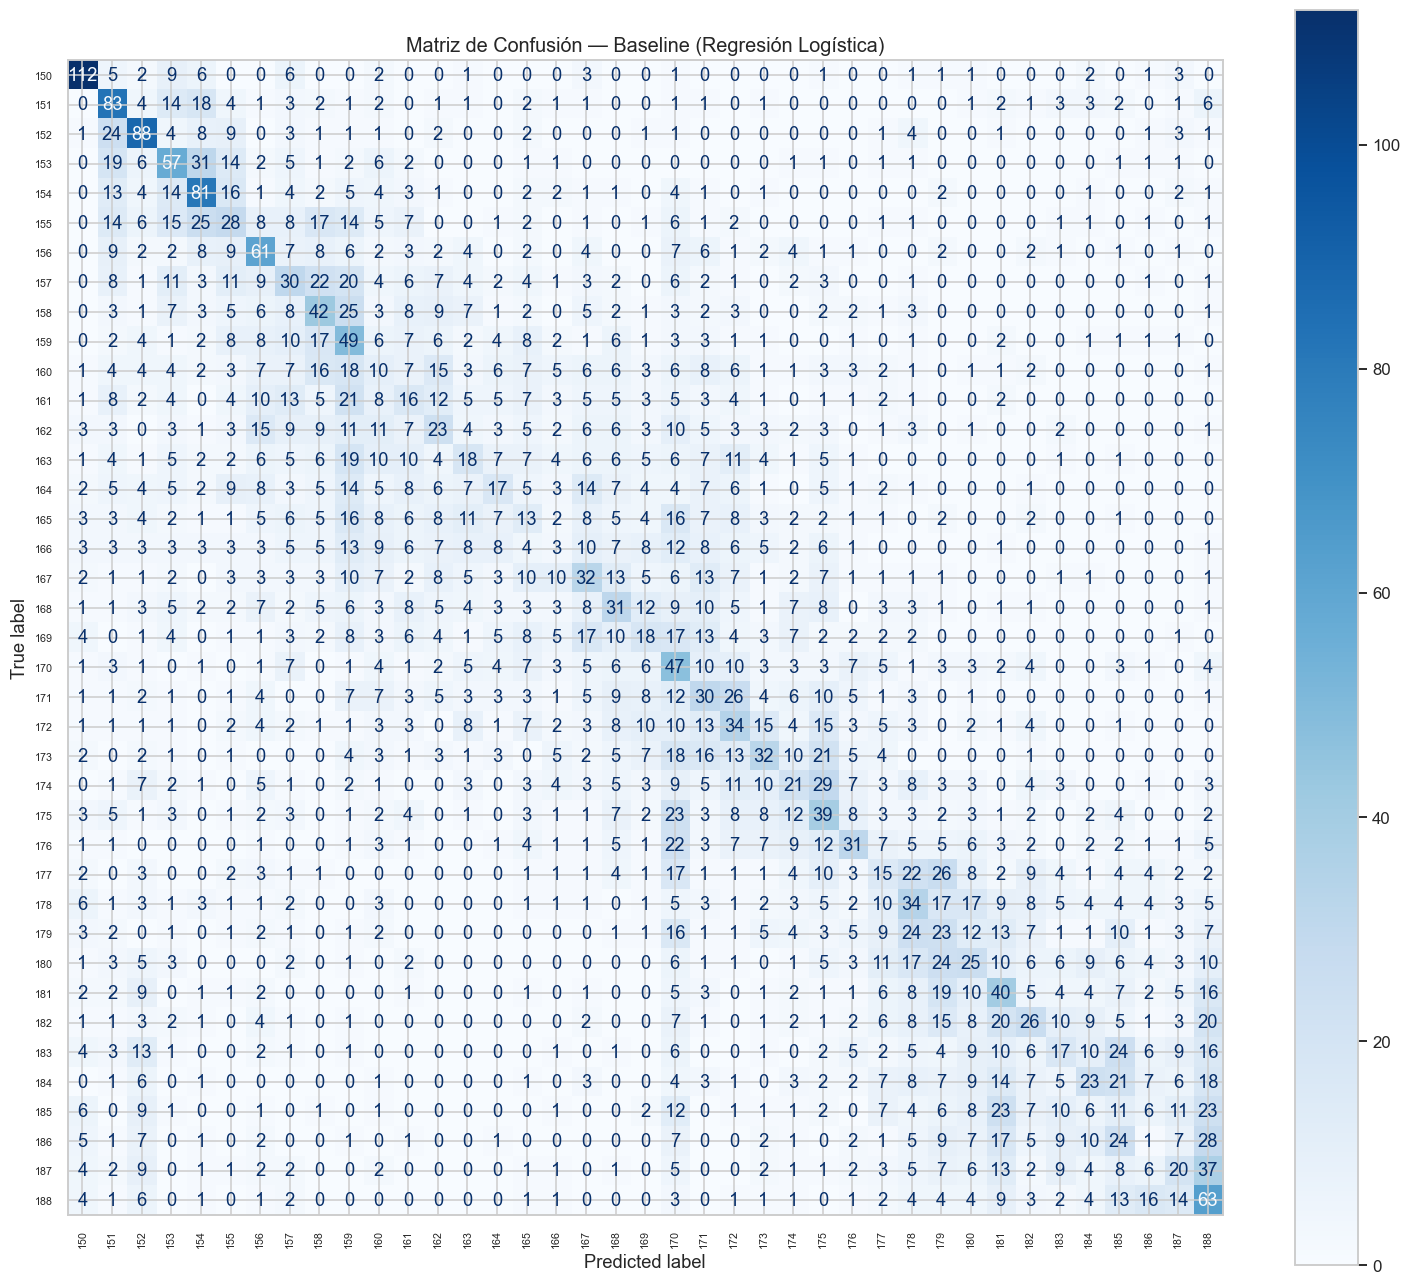

In [16]:
# ─────────────────────────────────────────────
# 6. CONSTRUCCIÓN DEL MODELO BASELINE
# ─────────────────────────────────────────────

# Entrenar el pipeline sobre los datos de entrenamiento
# El ColumnTransformer se ajusta solo sobre X_train — sin data leakage
pipeline.fit(X_train, y_train)
print("✅ Modelo baseline entrenado")

# ── Evaluación sobre el conjunto de prueba ──
y_pred_baseline = pipeline.predict(X_test)

acc_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline  = f1_score(y_test, y_pred_baseline, average='macro')

print(f"\n── Métricas baseline ──")
print(f"{'Accuracy:':<20} {acc_baseline:.4f}")
print(f"{'F1-macro:':<20} {f1_baseline:.4f}")

print("\n── Reporte completo por clase ──")
print(classification_report(y_test, y_pred_baseline))

# ── Matriz de confusión ──
fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline,
    ax=ax,
    colorbar=True,
    cmap='Blues'
)
ax.set_title('Matriz de Confusión — Baseline (Regresión Logística)', fontsize=13)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

El modelo baseline obtiene un **accuracy de 21.3%** y un **F1-macro de 20.2%**, lo que supera ampliamente el azar (1/39 ≈ 2.6%), siendo un punto de partida razonable para un problema de clasificación con 39 clases y textos cortos.

Analizando el reporte por clase y la matriz de confusión se observan patrones importantes:

- **Las décadas más antiguas clasifican mejor:** la década **150** (1500s) obtiene el mejor desempeño individual con F1 de 0.67, seguida de **152** (0.47) y **151** (0.41). Esto tiene sentido porque el español y latín del siglo XVI tienen un vocabulario muy distinto al de siglos posteriores, lo que facilita la discriminación.
- **Las décadas intermedias son las más confundidas:** décadas como **160**, **161**, **162**, **163** y **164** (1600-1640) obtienen F1 entre 0.06 y 0.16. En la matriz de confusión se observa claramente que estas clases se confunden entre sí, formando bloques de error en torno a la diagonal.
- **Los errores son temporalmente coherentes:** en la matriz de confusión los errores se concentran cerca de la diagonal principal y no hay predicciones cruzadas entre el siglo XVI y el siglo XIX. Cuando el modelo se equivoca, tiende a predecir la **década inmediatamente anterior o posterior**, no una época completamente distante — lo cual es un comportamiento esperado dado que décadas adyacentes comparten gran parte del vocabulario y las convenciones lingüísticas.

Este baseline establece el piso de referencia. En las siguientes secciones exploraremos modelos alternativos y optimización de hiperparámetros para mejorar estas métricas.

## 7. Exploración y Comparación de Modelos

Con el baseline establecido, exploramos ahora un conjunto más amplio de clasificadores para identificar cuál se adapta mejor a este problema. Evaluamos los siguientes modelos, todos compatibles con el requisito de usar únicamente técnicas clásicas de aprendizaje automático (sin deep learning):

| Modelo | Justificación |
|---|---|
| `LogisticRegression` | Baseline — lineal, interpretable, eficiente con TF-IDF |
| `DecisionTreeClassifier` | Captura relaciones no lineales, interpretable por reglas |
| `RandomForestClassifier` | Ensemble robusto, maneja bien alta dimensionalidad |
| `LinearSVC` | SVM lineal, generalmente fuerte en clasificación de texto |
| `ComplementNB` | Variante de Naive Bayes recomendada para clases balanceadas |
| `KNeighborsClassifier` | Referencia no paramétrica, útil para detectar si la geometría del espacio es informativa |

Todos los modelos se evalúan con el **mismo preprocesador** (TF-IDF + features numéricas) para que la comparación sea justa. La métrica principal es **F1-macro**, que trata todas las décadas por igual independientemente de su tamaño.

In [17]:
# ─────────────────────────────────────────────
# 7. EXPLORACIÓN Y COMPARACIÓN DE MODELOS
# ─────────────────────────────────────────────

# Preprocesador compartido — se instancia por separado
# para cada modelo para evitar que compartan estado interno
def build_preprocessor():
    return ColumnTransformer(transformers=[
        ('tfidf', TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            max_features=50000,
            sublinear_tf=True
        ), 'text_clean'),
        ('num', StandardScaler(), numeric_features)
    ])

# Diccionario para acumular resultados
resultados_acc = {}
resultados_f1  = {}

### 7.1 Regresión Logística

In [18]:
# ── 7.1 Regresión Logística ──
pipe_lr = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('clf', LogisticRegression(
        max_iter=1000, random_state=1, solver='saga', n_jobs=-1
    ))
])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

resultados_acc['Logistic Regression'] = accuracy_score(y_test, y_pred_lr)
resultados_f1['Logistic Regression']  = f1_score(y_test, y_pred_lr, average='macro')

print(f"Accuracy: {resultados_acc['Logistic Regression']:.4f}")
print(f"F1-macro: {resultados_f1['Logistic Regression']:.4f}")

Accuracy: 0.2079
F1-macro: 0.1947


### 7.2 Árbol de Decisión

In [19]:
# ── 7.2 Árbol de Decisión ──
pipe_dt = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('clf', DecisionTreeClassifier(random_state=1))
])
pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

resultados_acc['Decision Tree'] = accuracy_score(y_test, y_pred_dt)
resultados_f1['Decision Tree']  = f1_score(y_test, y_pred_dt, average='macro')

print(f"Accuracy: {resultados_acc['Decision Tree']:.4f}")
print(f"F1-macro: {resultados_f1['Decision Tree']:.4f}")

Accuracy: 0.1029
F1-macro: 0.1026


### 7.3 Random Forest

In [20]:
# ── 7.3 Random Forest ──
pipe_rf = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('clf', RandomForestClassifier(
        n_estimators=100, random_state=1, n_jobs=-1
    ))
])
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

resultados_acc['Random Forest'] = accuracy_score(y_test, y_pred_rf)
resultados_f1['Random Forest']  = f1_score(y_test, y_pred_rf, average='macro')

print(f"Accuracy: {resultados_acc['Random Forest']:.4f}")
print(f"F1-macro: {resultados_f1['Random Forest']:.4f}")

Accuracy: 0.1730
F1-macro: 0.1593


### 7.4 Linear SVC

In [21]:
# ── 7.4 Linear SVC ──
pipe_svc = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('clf', LinearSVC(max_iter=2000, random_state=1))
])
pipe_svc.fit(X_train, y_train)
y_pred_svc = pipe_svc.predict(X_test)

resultados_acc['Linear SVC'] = accuracy_score(y_test, y_pred_svc)
resultados_f1['Linear SVC']  = f1_score(y_test, y_pred_svc, average='macro')

print(f"Accuracy: {resultados_acc['Linear SVC']:.4f}")
print(f"F1-macro: {resultados_f1['Linear SVC']:.4f}")

Accuracy: 0.2032
F1-macro: 0.1987


### 7.5 Complement Naive Bayes

In [22]:
# ── 7.5 Complement Naive Bayes ──
# Nota: ComplementNB solo acepta valores no negativos.
# StandardScaler puede producir negativos en las features numéricas,
# por lo que usamos MinMaxScaler para esta rama numérica.
from sklearn.preprocessing import MinMaxScaler

def build_preprocessor_nb():
    return ColumnTransformer(transformers=[
        ('tfidf', TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            max_features=50000,
            sublinear_tf=True
        ), 'text_clean'),
        ('num', MinMaxScaler(), numeric_features)
    ])

pipe_nb = Pipeline([
    ('preprocessor', build_preprocessor_nb()),
    ('clf', ComplementNB())
])
pipe_nb.fit(X_train, y_train)
y_pred_nb = pipe_nb.predict(X_test)

resultados_acc['Complement NB'] = accuracy_score(y_test, y_pred_nb)
resultados_f1['Complement NB']  = f1_score(y_test, y_pred_nb, average='macro')

print(f"Accuracy: {resultados_acc['Complement NB']:.4f}")
print(f"F1-macro: {resultados_f1['Complement NB']:.4f}")

Accuracy: 0.1936
F1-macro: 0.1724


### 7.6 KNN

In [23]:
# ── 7.6 KNN ──
pipe_knn = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('clf', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
])
pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

resultados_acc['KNN'] = accuracy_score(y_test, y_pred_knn)
resultados_f1['KNN']  = f1_score(y_test, y_pred_knn, average='macro')

print(f"Accuracy: {resultados_acc['KNN']:.4f}")
print(f"F1-macro: {resultados_f1['KNN']:.4f}")

Accuracy: 0.0957
F1-macro: 0.0799


### 7.7 Tabla comparativa y visualización

── Tabla resumen ──


,Accuracy,F1-macro
Linear SVC,0.2032,0.1987
Logistic Regression,0.2079,0.1947
Complement NB,0.1936,0.1724
Random Forest,0.1730,0.1593
Decision Tree,0.1029,0.1026
KNN,0.0957,0.0799


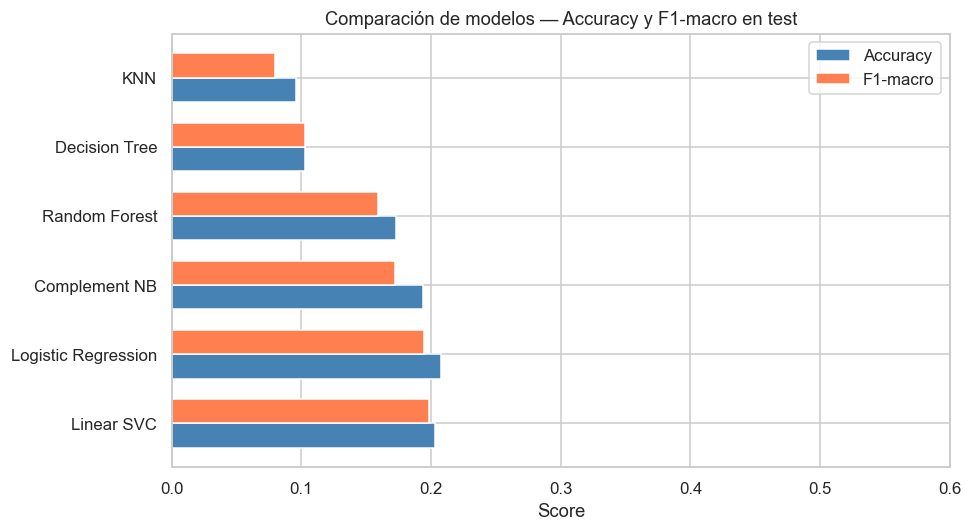

In [24]:
# ─────────────────────────────────────────────
# 7.7 TABLA COMPARATIVA Y VISUALIZACIÓN
# ─────────────────────────────────────────────
resultados_df = pd.DataFrame({
    'Accuracy': resultados_acc,
    'F1-macro': resultados_f1
}).sort_values('F1-macro', ascending=False)

print("── Tabla resumen ──")
display(resultados_df.round(4))

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(9, 5))
x     = np.arange(len(resultados_df))
width = 0.35

ax.barh(x - width/2, resultados_df['Accuracy'], width,
        label='Accuracy', color='steelblue')
ax.barh(x + width/2, resultados_df['F1-macro'], width,
        label='F1-macro', color='coral')

ax.set_xlabel('Score')
ax.set_title('Comparación de modelos — Accuracy y F1-macro en test')
ax.set_yticks(x)
ax.set_yticklabels(resultados_df.index)
ax.legend()
ax.set_xlim(0, 0.6)
plt.tight_layout()
plt.show()

### 7.7 Conclusiones de la Comparación

Los resultados muestran una separación clara entre tres grupos de modelos:

**Modelos lineales (mejores):** `Linear SVC` y `Logistic Regression` lideran la comparación con F1-macro de **0.198** y **0.195** respectivamente, prácticamente empatados. Esto era esperado: la representación TF-IDF genera un espacio de alta dimensionalidad donde los clasificadores lineales suelen ser muy efectivos porque cada dimensión (término) actúa como un indicador independiente de la época.

**Modelos intermedios:** `Complement NB` (F1: 0.173) y `Random Forest` (F1: 0.162) obtienen resultados moderados. Complement NB es sorprendentemente competitivo dado su simplicidad. Random Forest queda por debajo de los modelos lineales, posiblemente porque con 50.000 features TF-IDF los árboles individuales solo ven subconjuntos pequeños del vocabulario en cada split, perdiendo señal discriminativa.

**Modelos débiles:** `Decision Tree` (F1: 0.099) y `KNN` (F1: 0.080) tienen el peor desempeño. El árbol de decisión sin podar sobreajusta, y KNN sufre de la maldición de la dimensionalidad en espacios TF-IDF de 50.000 dimensiones.

**Decisión:** se selecciona **Linear SVC** como candidato para la búsqueda de hiperparámetros por tener el mejor F1-macro, aunque se incluirá también **Logistic Regression** dado que ambos están prácticamente empatados y la regresión logística ofrece mayor interpretabilidad a través de sus coeficientes por clase.